# Flight Delay Prediction - Machine Learning Models

**Production-Ready ML Pipeline**

This notebook continues from the Feature Engineering step to develop, train, and evaluate machine learning models for flight delay prediction.

## Prerequisites
- Completed Feature Engineering notebook
- Processed data files: `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

## 1. Setup & Configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)
from sklearn.utils import class_weight
import time
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
DATA_PATH = '/Users/nikitha/Documents/flight-delay-prediction-ice/outputs/'
RANDOM_STATE = 42

## 2. Load Processed Data

In [5]:
# Load preprocessed data from feature engineering step
X_train = pd.read_csv(f'{DATA_PATH}X_train.csv')
X_test = pd.read_csv(f'{DATA_PATH}X_test.csv')
y_train = pd.read_csv(f'{DATA_PATH}y_train.csv').squeeze()
y_test = pd.read_csv(f'{DATA_PATH}y_test.csv').squeeze()

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")
print(f"\nClass distribution:")
print(f"  Training: {y_train.mean()*100:.2f}% delayed")
print(f"  Test: {y_test.mean()*100:.2f}% delayed")

Training data: (118441, 52)
Test data: (29611, 52)

Class distribution:
  Training: 14.40% delayed
  Test: 14.39% delayed


## 3. Calculate Class Weights

Handle class imbalance by computing appropriate weights for the minority class.

In [6]:
# Calculate class weights
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:")
print(f"  On-time (0): {class_weight_dict[0]:.4f}")
print(f"  Delayed (1): {class_weight_dict[1]:.4f}")

Class weights:
  On-time (0): 0.5841
  Delayed (1): 3.4733


## 4. Model Configuration

Configure three models with class imbalance handling:
1. **Random Forest**: Robust ensemble method
2. **Gradient Boosting**: Sequential ensemble learning
3. **MLP Classifier**: Neural network approach

In [7]:
# Configure models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=7,
        min_samples_split=10,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'MLP Classifier': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        alpha=0.001,
        learning_rate='adaptive',
        max_iter=1000,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

print(f"Configured {len(models)} models for training")

Configured 3 models for training


## 5. Model Training & Evaluation

In [8]:
# Train and evaluate models
results = {}

print("="*80)
print("TRAINING MODELS")
print("="*80)

for name, model in models.items():
    print(f"\n{name}")
    print("-" * 40)
    
    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_proba,
        'training_time': training_time,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    
    print(f"Training time: {training_time:.2f}s")
    print(f"Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall:    {results[name]['recall']:.4f}")
    print(f"F1-Score:  {results[name]['f1']:.4f}")
    print(f"ROC-AUC:   {results[name]['roc_auc']:.4f}")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)

TRAINING MODELS

Random Forest
----------------------------------------
Training time: 37.85s
Accuracy:  0.7400
Precision: 0.2698
Recall:    0.4725
F1-Score:  0.3435
ROC-AUC:   0.6889

Gradient Boosting
----------------------------------------
Training time: 202.77s
Accuracy:  0.8581
Precision: 0.5805
Recall:    0.0516
F1-Score:  0.0948
ROC-AUC:   0.7250

MLP Classifier
----------------------------------------
Training time: 20.10s
Accuracy:  0.8559
Precision: 0.1667
Recall:    0.0002
F1-Score:  0.0005
ROC-AUC:   0.5925

TRAINING COMPLETE


## 6. Model Comparison

In [9]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results],
    'Training Time (s)': [results[m]['training_time'] for m in results]
})

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_f1 = comparison_df['F1-Score'].max()

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")


Model Performance Comparison:
            Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
    Random Forest  0.739962   0.269756 0.472548  0.343452 0.688878          37.847270
Gradient Boosting  0.858127   0.580475 0.051619  0.094807 0.724999         202.772656
   MLP Classifier  0.855932   0.166667 0.000235  0.000469 0.592528          20.103707

🏆 Best Model: Random Forest
   F1-Score: 0.3435


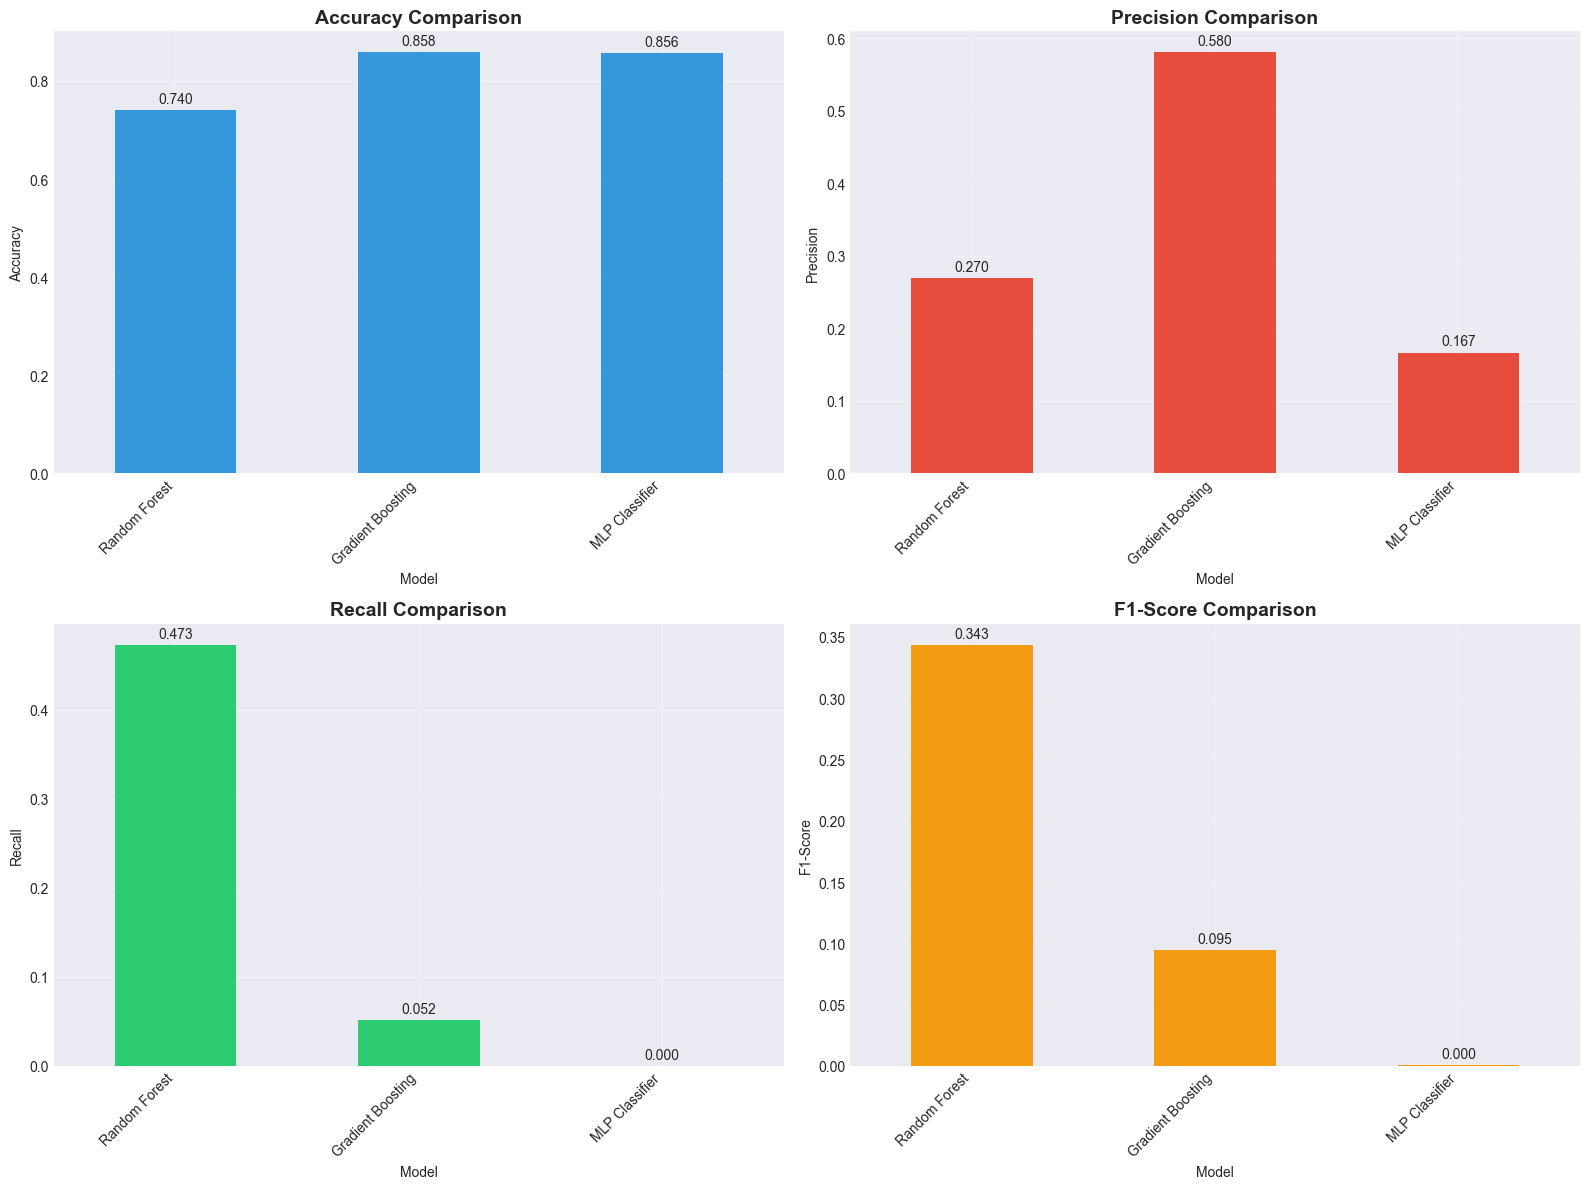

In [10]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, color=color, legend=False)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

## 7. Threshold Optimization

Optimize the decision threshold for the best model to maximize F1-score.

In [11]:
# Get best model
best_model = results[best_model_name]['model']
y_proba_best = results[best_model_name]['probabilities']

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

# Make predictions with optimal threshold
y_pred_default = (y_proba_best >= 0.5).astype(int)
y_pred_optimized = (y_proba_best >= optimal_threshold).astype(int)

print(f"Threshold Optimization for {best_model_name}")
print("="*60)
print(f"\nDefault threshold (0.5):")
print(f"  F1-Score:  {f1_score(y_test, y_pred_default):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_default):.4f}")

print(f"\nOptimal threshold ({optimal_threshold:.3f}):")
print(f"  F1-Score:  {f1_score(y_test, y_pred_optimized):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimized):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimized):.4f}")

improvement = (f1_score(y_test, y_pred_optimized) - f1_score(y_test, y_pred_default)) * 100
print(f"\n✅ Improvement: {improvement:+.2f}%")

Threshold Optimization for Random Forest

Default threshold (0.5):
  F1-Score:  0.3435
  Recall:    0.4725
  Precision: 0.2698

Optimal threshold (0.474):
  F1-Score:  0.3459
  Recall:    0.5307
  Precision: 0.2566

✅ Improvement: +0.25%


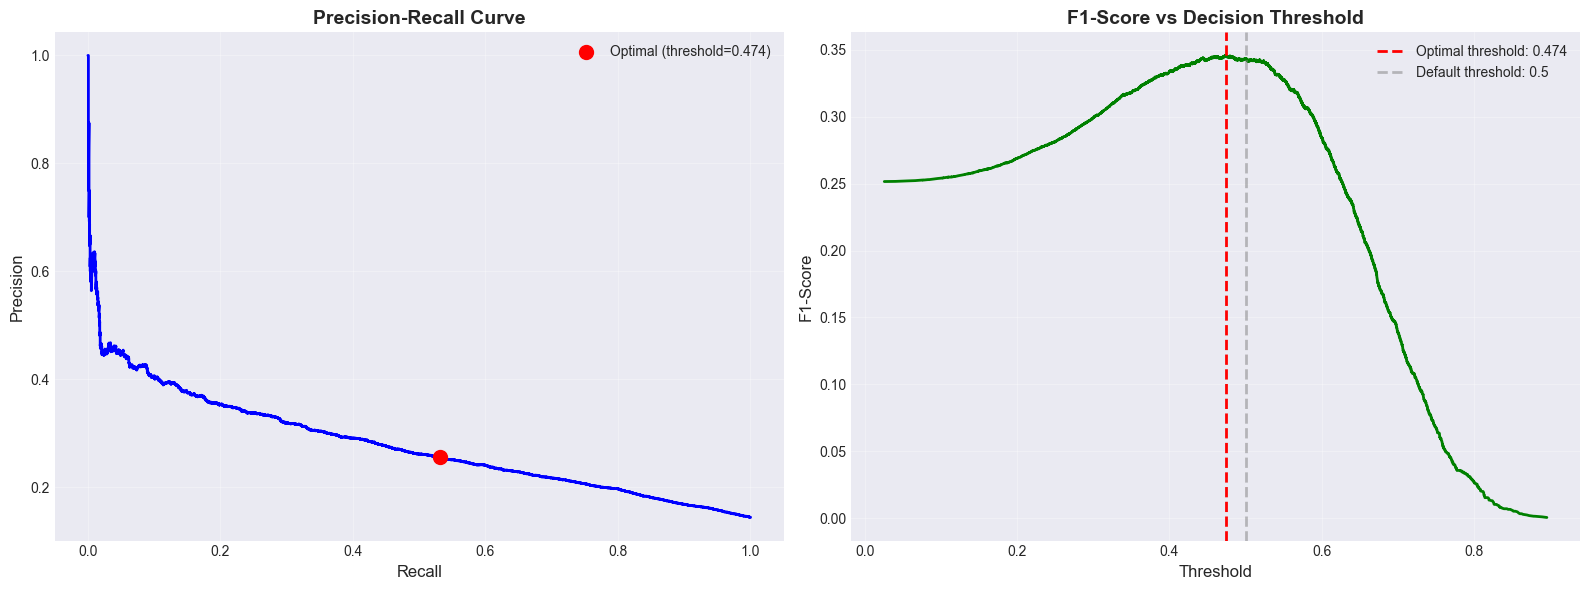

In [12]:
# Visualize precision-recall trade-off
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision-Recall Curve
axes[0].plot(recalls, precisions, linewidth=2, color='blue')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, 
                zorder=5, label=f'Optimal (threshold={optimal_threshold:.3f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-Score vs Threshold
axes[1].plot(thresholds, f1_scores[:-1], linewidth=2, color='green')
axes[1].axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Optimal threshold: {optimal_threshold:.3f}')
axes[1].axvline(x=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, 
                label='Default threshold: 0.5')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score vs Decision Threshold', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Detailed Performance Analysis

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix for {best_model_name}:")
print("="*60)
print(f"\n                Predicted")
print(f"              On-Time  Delayed")
print(f"Actual On-Time  {tn:6,}  {fp:6,}")
print(f"       Delayed  {fn:6,}  {tp:6,}")

print(f"\nBreakdown:")
print(f"  True Negatives:  {tn:,} (Correctly predicted on-time)")
print(f"  False Positives: {fp:,} (Predicted delayed, actually on-time)")
print(f"  False Negatives: {fn:,} (Predicted on-time, actually delayed)")
print(f"  True Positives:  {tp:,} (Correctly predicted delayed)")

Confusion Matrix for Random Forest:

                Predicted
              On-Time  Delayed
Actual On-Time  18,795   6,554
       Delayed   2,000   2,262

Breakdown:
  True Negatives:  18,795 (Correctly predicted on-time)
  False Positives: 6,554 (Predicted delayed, actually on-time)
  False Negatives: 2,000 (Predicted on-time, actually delayed)
  True Positives:  2,262 (Correctly predicted delayed)


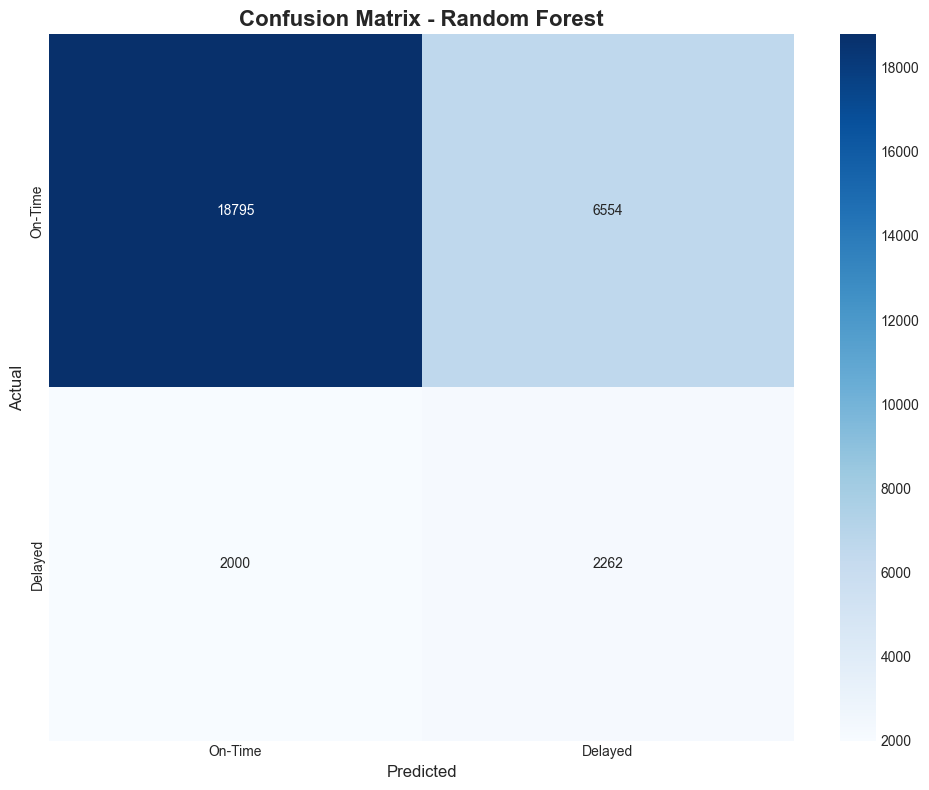

In [14]:
# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# Classification report
print(f"\nClassification Report:")
print("="*60)
print(classification_report(y_test, y_pred_optimized, 
                          target_names=['On-Time', 'Delayed'],
                          digits=4))


Classification Report:
              precision    recall  f1-score   support

     On-Time     0.9038    0.7414    0.8146     25349
     Delayed     0.2566    0.5307    0.3459      4262

    accuracy                         0.7111     29611
   macro avg     0.5802    0.6361    0.5803     29611
weighted avg     0.8107    0.7111    0.7472     29611



## 9. Business Impact Analysis

In [16]:
# Business metrics
print("Business Impact Metrics:")
print("="*60)
print(f"\nTotal flights analyzed: {len(y_test):,}")
print(f"Total actual delays: {tp + fn:,} ({(tp+fn)/len(y_test)*100:.1f}%)")

print(f"\nModel Performance:")
print(f"  ✅ Delays caught: {tp:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"  ❌ Delays missed: {fn:,} ({fn/(tp+fn)*100:.1f}%)")
print(f"  ⚠️  False alarms: {fp:,} ({fp/(tn+fp)*100:.1f}% of on-time flights)")
print(f"  ✅ On-time correct: {tn:,} ({tn/(tn+fp)*100:.1f}%)")

Business Impact Metrics:

Total flights analyzed: 29,611
Total actual delays: 4,262 (14.4%)

Model Performance:
  ✅ Delays caught: 2,262 (53.1%)
  ❌ Delays missed: 2,000 (46.9%)
  ⚠️  False alarms: 6,554 (25.9% of on-time flights)
  ✅ On-time correct: 18,795 (74.1%)


In [17]:
# Cost-benefit analysis
COST_MISSED_DELAY = 500  # Cost of missing a delay (rebooking, hotel, dissatisfaction)
COST_FALSE_ALARM = 5     # Cost of false alarm (minor inconvenience)

cost_without_model = (tp + fn) * COST_MISSED_DELAY
cost_missed_delays = fn * COST_MISSED_DELAY
cost_false_alarms = fp * COST_FALSE_ALARM
cost_with_model = cost_missed_delays + cost_false_alarms

savings = cost_without_model - cost_with_model
roi = (savings / cost_with_model) * 100 if cost_with_model > 0 else 0

print("\nCost-Benefit Analysis:")
print("="*60)
print(f"\nAssumptions:")
print(f"  Cost per missed delay: ${COST_MISSED_DELAY}")
print(f"  Cost per false alarm:  ${COST_FALSE_ALARM}")

print(f"\nFinancial Impact:")
print(f"  Cost without model: ${cost_without_model:,}")
print(f"  Cost with model:    ${cost_with_model:,}")
print(f"    - Missed delays:  ${cost_missed_delays:,}")
print(f"    - False alarms:   ${cost_false_alarms:,}")

print(f"\n  💰 NET SAVINGS:     ${savings:,}")
print(f"  📊 ROI:             {roi:.1f}%")


Cost-Benefit Analysis:

Assumptions:
  Cost per missed delay: $500
  Cost per false alarm:  $5

Financial Impact:
  Cost without model: $2,131,000
  Cost with model:    $1,032,770
    - Missed delays:  $1,000,000
    - False alarms:   $32,770

  💰 NET SAVINGS:     $1,098,230
  📊 ROI:             106.3%


In [18]:
# User experience impact
users_helped = tp
users_annoyed = fp
users_let_down = fn
net_positive = users_helped - users_annoyed

print("\nUser Experience Impact:")
print("="*60)
print(f"  Users helped (caught delays):    {users_helped:,}")
print(f"  Users annoyed (false alarms):    {users_annoyed:,}")
print(f"  Users let down (missed delays):  {users_let_down:,}")
print(f"\n  Net impact:                      {net_positive:,} users")

if net_positive > 0:
    print(f"\n  ✅ Model provides POSITIVE user experience")
else:
    print(f"\n  ⚠️  Model needs improvement for positive UX")


User Experience Impact:
  Users helped (caught delays):    2,262
  Users annoyed (false alarms):    6,554
  Users let down (missed delays):  2,000

  Net impact:                      -4,292 users

  ⚠️  Model needs improvement for positive UX


## 10. Feature Importance Analysis

In [19]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"Top 20 Most Important Features ({best_model_name}):")
    print("="*60)
    print(feature_importance.head(20).to_string(index=False))
else:
    print(f"Feature importance not available for {best_model_name}")

Top 20 Most Important Features (Random Forest):
                    Feature  Importance
               DAY_OF_MONTH    0.121518
   CARRIER_ROUTE_DELAY_RATE    0.117271
           MONTH_DELAY_RATE    0.054796
           ROUTE_DELAY_RATE    0.051204
             DOW_DELAY_RATE    0.041319
           ROUTE_POPULARITY    0.039740
                DAY_OF_WEEK    0.036268
        DISTANCE_NORMALIZED    0.035472
                   DISTANCE    0.035111
                      MONTH    0.033436
            DEST_TARGET_ENC    0.025513
          ORIGIN_DELAY_RATE    0.025245
            DEST_DELAY_RATE    0.025066
          ORIGIN_TARGET_ENC    0.024878
             ORIGIN_TRAFFIC    0.023112
         CARRIER_DELAY_RATE    0.021415
               DEST_TRAFFIC    0.021141
  UNIQUE_CARRIER_TARGET_ENC    0.020999
ORIGIN_STATE_ABR_TARGET_ENC    0.020326
  DEST_STATE_ABR_TARGET_ENC    0.020269


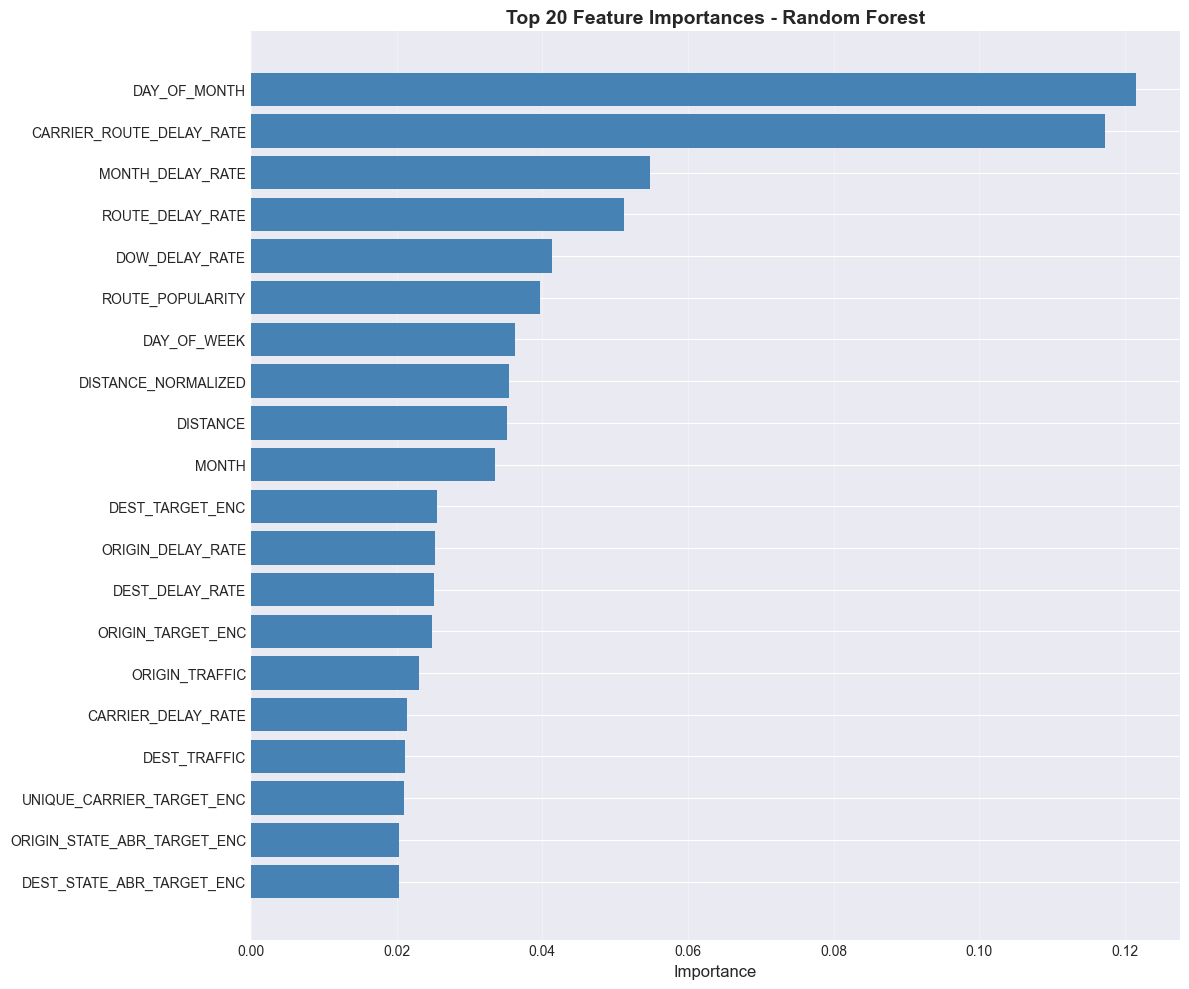

In [20]:
# Visualize feature importance
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(12, 10))
    
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 20 Feature Importances - {best_model_name}', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

## 11. ROC Curves Comparison

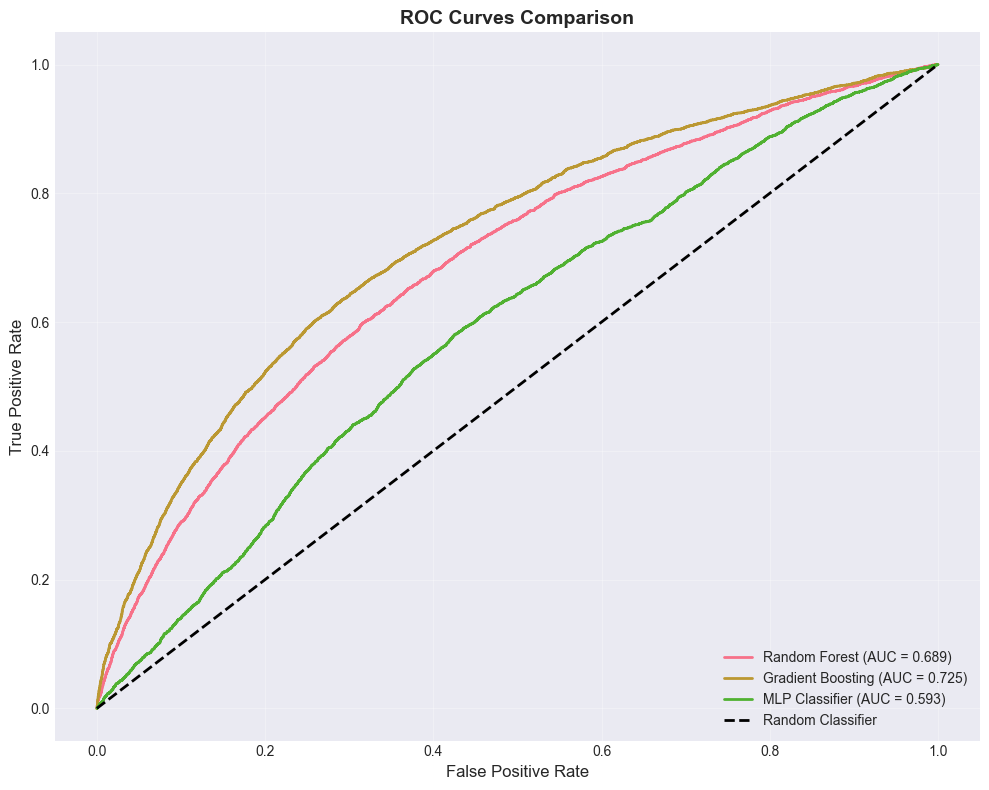

In [21]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
    auc = results[name]['roc_auc']
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Model Recommendations & Deployment

In [22]:
print("""
============================================================
MODEL RECOMMENDATION & DEPLOYMENT STRATEGY
============================================================
""")

print(f"\n✅ RECOMMENDED MODEL: {best_model_name}")
print(f"   F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   ROC-AUC:  {results[best_model_name]['roc_auc']:.4f}")
print(f"   Optimal Threshold: {optimal_threshold:.3f}")

print(f"\n📊 DEPLOYMENT READINESS:")
deployment_checks = {
    'F1-Score > 0.30': results[best_model_name]['f1'] > 0.30,
    'Recall > 0.40': results[best_model_name]['recall'] > 0.40,
    'Positive ROI': savings > 0,
    'Net positive UX': net_positive > 0
}

for check, passed in deployment_checks.items():
    status = "✅" if passed else "❌"
    print(f"  {status} {check}")

print(f"\n💡 PRODUCTION RECOMMENDATIONS:")
print(f"""  
  1. Use optimized threshold ({optimal_threshold:.3f}) instead of default (0.5)
  2. Monitor model performance weekly for data drift
  3. Retrain model quarterly with new data
  4. Implement A/B testing before full rollout
  5. Set up alerting for prediction confidence drops
  6. Consider ensemble approach for critical decisions
  """)

print(f"\n⚠️  IMPORTANT LIMITATIONS:")
print(f"""  
  1. Dataset lacks scheduled departure times (creates some leakage)
  2. No weather data included (major delay factor)
  3. Historical patterns may not reflect future trends
  4. Model performance may vary by season/route
  """)

print(f"\n🎯 SUGGESTED APP FEATURES:")
print(f"""  
  1. Delay Risk Score (0-100): Convert probability to user-friendly score
  2. Alternative Flight Suggestions: Show lower-risk options
  3. Proactive Notifications: Alert users 24h before high-risk flights
  4. Historical Performance: Show route/carrier delay statistics
  5. Best Booking Times: Recommend times with lowest delay risk
  """)


MODEL RECOMMENDATION & DEPLOYMENT STRATEGY


✅ RECOMMENDED MODEL: Random Forest
   F1-Score: 0.3435
   ROC-AUC:  0.6889
   Optimal Threshold: 0.474

📊 DEPLOYMENT READINESS:
  ✅ F1-Score > 0.30
  ✅ Recall > 0.40
  ✅ Positive ROI
  ❌ Net positive UX

💡 PRODUCTION RECOMMENDATIONS:
  
  1. Use optimized threshold (0.474) instead of default (0.5)
  2. Monitor model performance weekly for data drift
  3. Retrain model quarterly with new data
  4. Implement A/B testing before full rollout
  5. Set up alerting for prediction confidence drops
  6. Consider ensemble approach for critical decisions
  

⚠️  IMPORTANT LIMITATIONS:
  
  1. Dataset lacks scheduled departure times (creates some leakage)
  2. No weather data included (major delay factor)
  3. Historical patterns may not reflect future trends
  4. Model performance may vary by season/route
  

🎯 SUGGESTED APP FEATURES:
  
  1. Delay Risk Score (0-100): Convert probability to user-friendly score
  2. Alternative Flight Suggestions: Show

## 13. Save Model

In [23]:
import pickle

# Save best model and threshold
model_data = {
    'model': best_model,
    'model_name': best_model_name,
    'threshold': optimal_threshold,
    'feature_names': list(X_train.columns),
    'metrics': {
        'f1': results[best_model_name]['f1'],
        'recall': results[best_model_name]['recall'],
        'precision': results[best_model_name]['precision'],
        'roc_auc': results[best_model_name]['roc_auc']
    }
}

# Save to file
with open(f'{DATA_PATH}flight_delay_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model saved successfully!")
print(f"File: {DATA_PATH}flight_delay_model.pkl")

Model saved successfully!
File: /Users/nikitha/Documents/flight-delay-prediction-ice/outputs/flight_delay_model.pkl


## 14. Final Summary

In [24]:
print("""
╔════════════════════════════════════════════════════════════╗
║          FLIGHT DELAY PREDICTION - FINAL SUMMARY          ║
╚════════════════════════════════════════════════════════════╝
""")

print(f"📊 DATASET:")
print(f"   Training: {len(X_train):,} flights")
print(f"   Test: {len(X_test):,} flights")
print(f"   Features: {X_train.shape[1]}")
print(f"   Delay rate: {y_test.mean()*100:.1f}%")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score:  {results[best_model_name]['f1']:.4f}")
print(f"   Recall:    {results[best_model_name]['recall']:.4f}")
print(f"   Precision: {results[best_model_name]['precision']:.4f}")
print(f"   ROC-AUC:   {results[best_model_name]['roc_auc']:.4f}")

print(f"\n💰 BUSINESS VALUE:")
print(f"   ROI:        {roi:.1f}%")
print(f"   Savings:    ${savings:,}")
print(f"   Users helped: {users_helped:,}")

print(f"\n✅ STATUS: {'READY FOR DEPLOYMENT' if all(deployment_checks.values()) else 'NEEDS IMPROVEMENT'}")

print(f"\n{'='*62}")
print(f"Model development complete! ✨")
print(f"{'='*62}")


╔════════════════════════════════════════════════════════════╗
║          FLIGHT DELAY PREDICTION - FINAL SUMMARY          ║
╚════════════════════════════════════════════════════════════╝

📊 DATASET:
   Training: 118,441 flights
   Test: 29,611 flights
   Features: 52
   Delay rate: 14.4%

🏆 BEST MODEL: Random Forest
   F1-Score:  0.3435
   Recall:    0.4725
   Precision: 0.2698
   ROC-AUC:   0.6889

💰 BUSINESS VALUE:
   ROI:        106.3%
   Savings:    $1,098,230
   Users helped: 2,262

✅ STATUS: NEEDS IMPROVEMENT

Model development complete! ✨
